In [11]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load feature dataset
features_df = pd.read_csv("../data/features.csv")

print("Dataset Shape:", features_df.shape)
print("\nClass Distribution:")
print(features_df["Label"].value_counts().sort_index())

Dataset Shape: (900, 9)

Class Distribution:
Label
0    890
1     10
Name: count, dtype: int64


In [12]:
# Separate features and labels

X = features_df.drop("Label", axis=1)
y = features_df["Label"]

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

Features Shape: (900, 8)
Labels Shape: (900,)

Feature Columns:
['Mean', 'Std', 'Variance', 'Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']


In [13]:
# Split dataset into training and testing sets
# Stratify ensures both sets contain seizure samples

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting Class Distribution:")
print(y_test.value_counts().sort_index())

Training Features Shape: (720, 8)
Testing Features Shape: (180, 8)
Training Labels Shape: (720,)
Testing Labels Shape: (180,)

Training Class Distribution:
Label
0    712
1      8
Name: count, dtype: int64

Testing Class Distribution:
Label
0    178
1      2
Name: count, dtype: int64


In [14]:
# Train Random Forest with class balancing

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")


Random Forest model trained successfully!


In [15]:
# Generate predictions on the test set

y_pred = rf_model.predict(X_test)

print("Predictions generated successfully!")

print("\nActual Class Distribution:")
print(y_test.value_counts().sort_index())

print("\nPredicted Class Distribution:")
print(pd.Series(y_pred).value_counts().sort_index())

Predictions generated successfully!

Actual Class Distribution:
Label
0    178
1      2
Name: count, dtype: int64

Predicted Class Distribution:
0    180
Name: count, dtype: int64


In [16]:
# Evaluate the Random Forest model

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Seizure"],
        zero_division=0
    )
)

Confusion Matrix:
[[178   0]
 [  2   0]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       178
     Seizure       0.00      0.00      0.00         2

    accuracy                           0.99       180
   macro avg       0.49      0.50      0.50       180
weighted avg       0.98      0.99      0.98       180



In [17]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.9888888888888889
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0


In [18]:
# Calculate Sensitivity and Specificity

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

print("\nSensitivity (Recall):", sensitivity)
print("Specificity:", specificity)

True Negatives (TN): 178
False Positives (FP): 0
False Negatives (FN): 2
True Positives (TP): 0

Sensitivity (Recall): 0.0
Specificity: 1.0


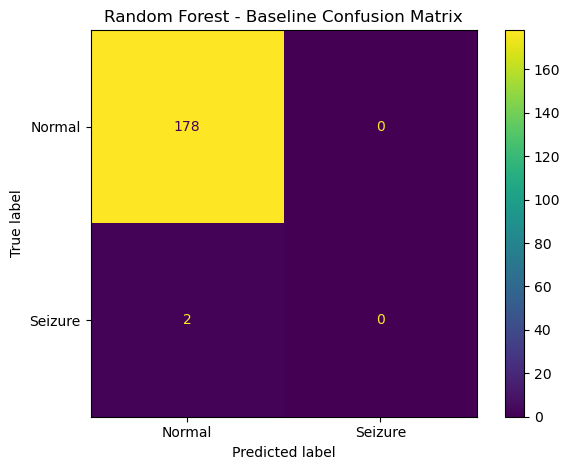

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Seizure"]
)

disp.plot()

plt.title("Random Forest - Baseline Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../images/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Calculate Sensitivity and Specificity

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

Sensitivity: 0.0
Specificity: 1.0


In [21]:
import joblib

# Save the trained Random Forest model
joblib.dump(
    rf_model,
    "../models/random_forest_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [22]:
# Get prediction probabilities for the test set

y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Prediction probabilities generated successfully!")
print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())

Prediction probabilities generated successfully!
Minimum probability: 0.0
Maximum probability: 0.13


In [23]:
# Test different probability thresholds

thresholds = [0.50, 0.20, 0.10, 0.05, 0.01]

for threshold in thresholds:
    
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    cm_threshold = confusion_matrix(y_test, y_pred_threshold)
    
    tn, fp, fn, tp = cm_threshold.ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"\nThreshold: {threshold}")
    print("Confusion Matrix:")
    print(cm_threshold)
    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)


Threshold: 0.5
Confusion Matrix:
[[178   0]
 [  2   0]]
Sensitivity: 0.0
Specificity: 1.0

Threshold: 0.2
Confusion Matrix:
[[178   0]
 [  2   0]]
Sensitivity: 0.0
Specificity: 1.0

Threshold: 0.1
Confusion Matrix:
[[171   7]
 [  2   0]]
Sensitivity: 0.0
Specificity: 0.9606741573033708

Threshold: 0.05
Confusion Matrix:
[[156  22]
 [  1   1]]
Sensitivity: 0.5
Specificity: 0.8764044943820225

Threshold: 0.01
Confusion Matrix:
[[113  65]
 [  1   1]]
Sensitivity: 0.5
Specificity: 0.6348314606741573


In [24]:
# Final threshold-selected predictions

best_threshold = 0.05

y_pred_final = (y_prob >= best_threshold).astype(int)

print("Selected Threshold:", best_threshold)

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nFinal Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Normal", "Seizure"],
        zero_division=0
    )
)

Selected Threshold: 0.05

Final Confusion Matrix:
[[156  22]
 [  1   1]]

Final Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.88      0.93       178
     Seizure       0.04      0.50      0.08         2

    accuracy                           0.87       180
   macro avg       0.52      0.69      0.51       180
weighted avg       0.98      0.87      0.92       180

